<table>
  <tr>
    <td>Minería de Datos y Paradigma BigData (<b>MIN</b>) - Facultad de Informática - UCM</td>
    <td><img src="https://biblioteca.ucm.es/data/cont/media/www/pag-88746//escudo.jpg" width="110"/></td>
  </tr>
</table>

# Aprendizaje No Supervisado: Clustering
## Análisis de luchadores de UFC y Matchmaking para UFC Freedom 250 (Casa Blanca)
Pablo C. Cañizares

---
## Estadísticas de Luchadores de UFC

Este dataset contiene información estadística de **4.447 luchadores** que han competido en la UFC (Ultimate Fighting Championship). Cada fila representa a un luchador y las columnas recogen tanto datos biográficos como métricas de rendimiento en combate.

## Columnas del Dataset

**Datos identificativos:**
- **NAME**: Nombre completo del luchador.
- **RECORD**: Récord profesional (victorias-derrotas-empates).
- **NICKNAME**: Apodo del luchador.
- **HEIGHT**: Altura (en pies y pulgadas).
- **WEIGHT**: Peso (en libras).
- **REACH**: Envergadura (en pulgadas).
- **STANCE**: Guardia de pelea (Orthodox, Southpaw, Switch).
- **DOB**: Fecha de nacimiento.
- **LAST_FIGHT**: Fecha de la última pelea del luchador (o "No se encontró ninguna pelea previa").
- **GENDER**: Género del luchador (*Man* / *Woman*)
  
**Métricas de striking (golpeo):**
- **SLpM**: Significant Strikes Landed per Minute — Golpes significativos conectados por minuto.
- **Str Acc**: Striking Accuracy — Precisión de golpeo (%).
- **SApM**: Significant Strikes Absorbed per Minute — Golpes significativos recibidos por minuto.
- **Str Def**: Striking Defense — Defensa de golpeo, porcentaje de golpes esquivados (%).

**Métricas de grappling (lucha/suelo):**
- **TD Avg**: Takedown Average — Media de derribos por cada 15 minutos de pelea.
- **TD Acc**: Takedown Accuracy — Precisión de derribos (%).
- **TD Def**: Takedown Defense — Defensa de derribos (%).
- **Sub Avg**: Submission Average — Media de intentos de sumisión por cada 15 minutos.

## Ejercicio 1: Descubrir arquetipos de luchadores UFC

En la UFC conviven estilos de pelea muy distintos: strikers puros que buscan el KO de pie, grapplers que dominan en el suelo, luchadores completos que combinan ambas facetas, y perfiles más defensivos o conservadores.

El objetivo es aplicar técnicas de **clustering** (aprendizaje no supervisado) para descubrir de forma automática estos arquetipos a partir de las estadísticas de rendimiento de los luchadores. Esto nos permitirá:
1. Clasificar a cada luchador en un grupo según su estilo de pelea.
2. Interpretar qué define a cada arquetipo.
3. Visualizar cómo se distribuyen los luchadores en el espacio de características.

### ¿Cómo lo haremos?
1. **Carga y limpieza** del dataset (parsear porcentajes, alturas, pesos; tratar valores missing).
2. **Selección de features** numéricas de rendimiento.
3. **Estandarización** de las features (StandardScaler).
4. **Aplicación de K-Means** con diferentes valores de k.
5. **Selección del k óptimo** mediante el método del codo (elbow) y el índice de silhouette.
6. **Visualización** con PCA en 2D y dendrograma jerárquico.
7. **Interpretación** de los clusters resultantes.

### Importar librerías y cargar el dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import euclidean
import warnings
warnings.filterwarnings('ignore')

#plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [25]:
# Cargar el dataset extendido
df_raw = pd.read_csv("all_fighters_ext_fixed.csv")
print(f"Dataset cargado: {df_raw.shape[0]} luchadores, {df_raw.shape[1]} columnas")
print(f"\nColumnas: {list(df_raw.columns)}")
df_raw.head()

Dataset cargado: 4485 luchadores, 18 columnas

Columnas: ['NAME', 'RECORD', 'NICKNAME', 'LAST_FIGHT', 'GENDER', 'HEIGHT', 'WEIGHT', 'REACH', 'STANCE', 'DOB', 'SLpM', 'Str. Acc.', 'SApM', 'Str. Def.', 'TD Avg.', 'TD Acc.', 'TD Def.', 'Sub. Avg.']


,NAME,RECORD,NICKNAME,LAST_FIGHT,GENDER,HEIGHT,WEIGHT,REACH,STANCE,DOB,SLpM,Str. Acc.,SApM,Str. Def.,TD Avg.,TD Acc.,TD Def.,Sub. Avg.
0,Tom Aaron,5-3-0,NaN,"Dec. 04, 2010",Man,--,155 lbs.,--,NaN,"Jul 13, 1978",0.00,0%,0.00,0%,0.00,0%,0%,0.0
1,Danny Abbadi,4-6-0,The Assassin,"Sep. 23, 2006",Man,"5' 11""",155 lbs.,--,Orthodox,"Jul 03, 1983",3.29,38%,4.41,57%,0.00,0%,77%,0.0
2,Nariman Abbasov,28-4-0,Bayraktar,"Sep. 06, 2022",Man,"5' 8""",155 lbs.,"66""",Orthodox,"Feb 01, 1994",3.00,20%,5.67,46%,0.00,0%,66%,0.0
3,Darion Abbey,9-5-0,NaN,"Aug. 26, 2025",Man,"6' 2""",265 lbs.,"80""",Orthodox,"Feb 25, 1993",8.44,50%,14.06,28%,0.00,0%,0%,0.0
4,David Abbott,10-15-0,Tank,"Feb. 16, 2008",Man,"6' 0""",265 lbs.,--,Switch,"Apr 26, 1965",1.35,30%,3.55,38%,1.07,33%,66%,0.0


### Exploración y limpieza de datos

El dataset presenta varios retos:
- Porcentajes almacenados como texto ("48%").
- Alturas en formato imperial (5' 11").
- Pesos con "lbs." como texto.
- Valores missing codificados como "--".
- Campo LAST_FIGHT con texto especial para luchadores sin peleas.

In [26]:
print("Valores LAST_FIGHT especiales")
no_fight = df_raw['LAST_FIGHT'].str.contains('No se encontr', na=False).sum()
print(f"Luchadores sin pelea registrada: {no_fight}")

print("\nValores '--' (missing codificado)")
for col in df_raw.columns:
    count = (df_raw[col] == '--').sum()
    if count > 0:
        print(f"  {col}: {count}")

Valores LAST_FIGHT especiales
Luchadores sin pelea registrada: 423

Valores '--' (missing codificado)
  HEIGHT: 346
  WEIGHT: 86
  REACH: 1968
  DOB: 508


In [27]:
# Limpieza completa
df = df_raw.copy()

# Parseamos porcentajes (quitar "%" y convertir a float)
pct_columns = ['Str. Acc.', 'Str. Def.', 'TD Acc.', 'TD Def.']
for col in pct_columns:
    df[col] = df[col].astype(str).str.replace('%', '', regex=False).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Parseamos WEIGHT (quitar " lbs.")
df['WEIGHT'] = df['WEIGHT'].astype(str).str.replace(' lbs.', '', regex=False)
df['WEIGHT'] = pd.to_numeric(df['WEIGHT'], errors='coerce')

# Parseamos HEIGHT (formato 5' 11" a centímetros)
def parse_height(h):
    if pd.isna(h) or h == '--':
        return np.nan
    h = str(h).replace('"', '').strip()
    parts = h.split("'")
    if len(parts) == 2:
        feet = int(parts[0].strip())
        inches = int(parts[1].strip()) if parts[1].strip() else 0
        return round(feet * 30.48 + inches * 2.54, 1)
    return np.nan

df['HEIGHT_CM'] = df['HEIGHT'].apply(parse_height)

# Parseamos REACH (quitar comillas)
df['REACH'] = df['REACH'].astype(str).str.replace('"', '', regex=False)
df['REACH'] = pd.to_numeric(df['REACH'], errors='coerce')

# Parseamos RECORD (extraer wins, losses)
df['WINS'] = df['RECORD'].str.split('-').str[0].astype(int)
df['LOSSES'] = df['RECORD'].str.split('-').str[1].astype(int)

# Parseamos LAST_FIGHT (a datetime) +  "No se encontró ninguna pelea previa." → NaN explícitamente
mask_no_fight = df['LAST_FIGHT'].str.contains('No se encontr', na=False)
df.loc[mask_no_fight, 'LAST_FIGHT'] = np.nan
df['LAST_FIGHT_DATE'] = pd.to_datetime(df['LAST_FIGHT'], format='mixed', errors='coerce')
n_no_fight = mask_no_fight.sum()
n_nat = df['LAST_FIGHT_DATE'].isna().sum()
print(f"LAST_FIGHT: {n_no_fight} luchadores sin pelea registrada → marcados como NaN")
if n_nat > n_no_fight:
    print(f"   + {n_nat - n_no_fight} fechas adicionales no parseables → NaN")


print("\nLimpieza completada.")
print(f"\nEjemplo tras limpieza:")
df.head(10)

LAST_FIGHT: 423 luchadores sin pelea registrada → marcados como NaN
   + 4062 fechas adicionales no parseables → NaN

Limpieza completada.

Ejemplo tras limpieza:


,NAME,RECORD,NICKNAME,LAST_FIGHT,GENDER,HEIGHT,WEIGHT,REACH,STANCE,DOB,...,SApM,Str. Def.,TD Avg.,TD Acc.,TD Def.,Sub. Avg.,HEIGHT_CM,WINS,LOSSES,LAST_FIGHT_DATE
0,Tom Aaron,5-3-0,NaN,"Dec. 04, 2010",Man,--,155.0,NaN,NaN,"Jul 13, 1978",...,0.00,0,0.00,0,0,0.0,NaN,5,3,NaT
1,Danny Abbadi,4-6-0,The Assassin,"Sep. 23, 2006",Man,"5' 11""",155.0,NaN,Orthodox,"Jul 03, 1983",...,4.41,57,0.00,0,77,0.0,180.3,4,6,NaT
2,Nariman Abbasov,28-4-0,Bayraktar,"Sep. 06, 2022",Man,"5' 8""",155.0,66.0,Orthodox,"Feb 01, 1994",...,5.67,46,0.00,0,66,0.0,172.7,28,4,NaT
3,Darion Abbey,9-5-0,NaN,"Aug. 26, 2025",Man,"6' 2""",265.0,80.0,Orthodox,"Feb 25, 1993",...,14.06,28,0.00,0,0,0.0,188.0,9,5,NaT
4,David Abbott,10-15-0,Tank,"Feb. 16, 2008",Man,"6' 0""",265.0,NaN,Switch,"Apr 26, 1965",...,3.55,38,1.07,33,66,0.0,182.9,10,15,NaT
5,Hamdy Abdelwahab,7-1-0 (1 NC),The Hammer,"Oct. 25, 2025",Man,"6' 2""",265.0,72.0,Southpaw,"Jan 22, 1993",...,3.67,51,3.25,65,100,0.0,188.0,7,1,NaT
6,Farida Abdueva,6-1-0,NaN,NaN,Woman,--,115.0,NaN,NaN,"May 15, 2004",...,0.00,0,0.00,0,0,0.0,NaN,6,1,NaT
7,Mansur Abdul-Malik,9-1-1,NaN,"Mar. 28, 2026",Man,"6' 2""",185.0,80.0,Orthodox,"Oct 07, 1997",...,4.49,46,1.65,41,83,0.3,188.0,9,1,NaT
8,Shamil Abdurakhimov,20-8-0,Abrek,"Jan. 21, 2023",Man,"6' 3""",235.0,76.0,Orthodox,"Sep 02, 1981",...,3.02,55,1.01,23,45,0.1,190.5,20,8,NaT
9,Hiroyuki Abe,8-15-3 (1 NC),Abe Ani,"Aug. 27, 2006",Man,"5' 6""",145.0,NaN,Orthodox,"Feb 09, 1970",...,3.11,63,0.00,0,33,0.0,167.6,8,15,NaT


### Ejercicio 1.1: Filtro inicial de dataset (2 puntos)

Escoge del dataset las características necesarias para encontrar arquetipos distintos de lucha. Debes entender que si escoges variables que no tengan que ver con el estilo de lucha, puedes meter ruido a la clasificacion.

Por otra parte, debes escoger únicamente peleadores de género másculino, y con una última pelea al menos en 2023. 

In [28]:
# Solucion
# Features
feature_columns = ['SLpM', 'Str. Acc.', 'SApM', 'Str. Def.', 'TD Avg.', 'TD Acc.', 'TD Def.', 'Sub. Avg.']

# Estadísticas seleccionadas (no todo a 0)
mask_stats = df[feature_columns].sum(axis=1) > 0

# Solo hombres
mask_male = (df['GENDER'] == 'Man')

# Activos (última pelea desde 2023-01-01), si tienen vlor a na en esta columna, quiere decir que estan activos también
CUTOFF_DATE = pd.Timestamp('2023-01-01')
mask_active_or_nat = (df['LAST_FIGHT_DATE'] >= CUTOFF_DATE) | (df['LAST_FIGHT_DATE'].isna())

# Aplicar filtros
df_clean = df[mask_stats & mask_male & mask_active_or_nat].copy()

# Borrar aquellos que tengan nulos en las columnas objetivo
df_clean = df_clean.dropna(subset=feature_columns)

print(f"=== Pipeline de filtrado ===")
print(f"  Dataset original:                    {len(df):>5}")
print(f"  Con stats de combate (no todo 0):    {mask_stats.sum():>5}")
print(f"  Hombres:          {(mask_stats & mask_male).sum():>5}")
print(f"  Activos (última pelea ≥ 2023):       {(mask_stats & mask_active_or_nat).sum():>5}")
print(f"  Tras eliminar NaN en features:       {len(df_clean):>5}")
print(f"\n📊 Dataset final: {len(df_clean)} peleadores masculinos activos")

# Rango de fechas
print(f"\nRango de última pelea: {df_clean['LAST_FIGHT_DATE'].min().strftime('%Y-%m-%d')} — {df_clean['LAST_FIGHT_DATE'].max().strftime('%Y-%m-%d')}")

=== Pipeline de filtrado ===
  Dataset original:                     4485
  Con stats de combate (no todo 0):     3765
  Hombres:           3386
  Activos (última pelea ≥ 2023):        3765
  Tras eliminar NaN en features:        3386

📊 Dataset final: 3386 peleadores masculinos activos


ValueError: NaTType does not support strftime

### Ejercicio 1.2: Estandarización (0.5 puntos)

Las features tienen **escalas diferentes**:. Si no estandarizamos, las variables con mayor rango dominarán el cálculo de distancias y el clustering se sesgará hacia ellas.

El **StandardScaler** transforma cada feature para que tenga media 0 y desviación estándar 1:

$$z = \frac{x - \mu}{\sigma}$$

In [7]:
#solución
# Estandarizar
X = df_clean[feature_columns]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features seleccionadas:", feature_columns)
print(f"Matriz de datos: {X_scaled.shape}")
print(f"\nMedia tras escalar (≈0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std tras escalar  (≈1): {X_scaled.std(axis=0).round(4)}")

Features seleccionadas: ['SLpM', 'Str. Acc.', 'SApM', 'Str. Def.', 'TD Avg.', 'TD Acc.', 'TD Def.', 'Sub. Avg.']
Matriz de datos: (3386, 8)

Media tras escalar (≈0): [-0. -0.  0.  0.  0. -0. -0. -0.]
Std tras escalar  (≈1): [1. 1. 1. 1. 1. 1. 1. 1.]


### Ejercicio 1.3:  Análisis de correlación (0.5 puntos)
Haz la matriz de corelación de los peleadores

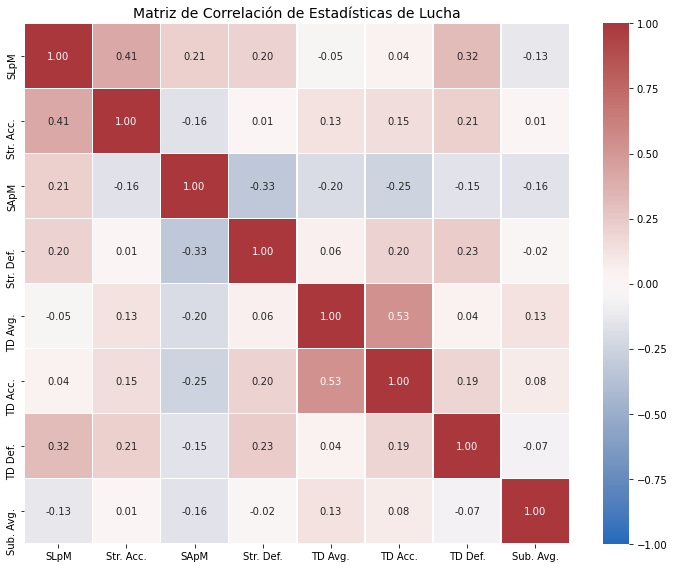

In [8]:
#solución
# Matriz de correlación
plt.figure(figsize=(10, 8))
corr_matrix = X.corr()
# usamos el heatmap para representar la correlación
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Estadísticas de Lucha", fontsize=14)
plt.tight_layout()
plt.show()

### Ejercicio 1.4:  Selección del número de clusters (k) (2.5 puntos)

Usamos dos criterios complementarios:
- **Método del codo (Elbow)**: busca el punto donde la inercia deja de descender significativamente.
- **Índice de silhouette**: mide la cohesión y separación de los clusters (mayor = mejor).

**Nota sobre la interpretabilidad**: k=2 suele maximizar el silhouette en estos datos, pero produce solo una división gruesa (buenos/malos) sin valor para distinguir arquetipos de estilo. Por ello seleccionamos el **mejor k ≥ 3**, que permite descubrir perfiles de pelea diferenciados.

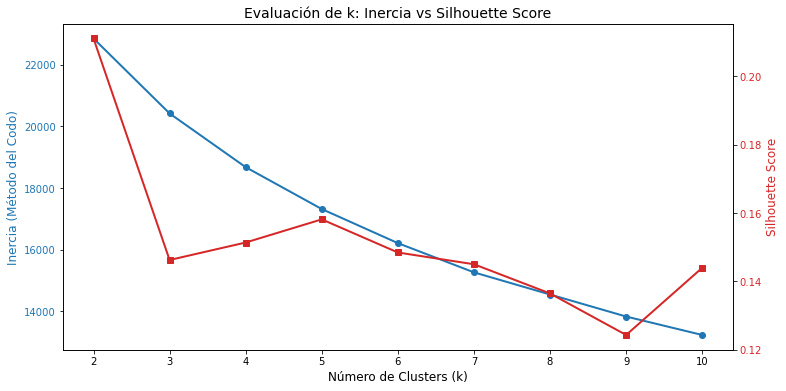

In [9]:
#solución
# Elbow + Silhouette para k de 2 a 10
inertias = []
silhouette_vals = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, labels))

# Graficamos con doble eje Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Inercia
ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
ax1.set_ylabel('Inercia (Método del Codo)', color='tab:blue', fontsize=12)
ax1.plot(k_range, inertias, marker='o', color='tab:blue', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Silhouette
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red', fontsize=12)
ax2.plot(k_range, silhouette_vals, marker='s', color='tab:red', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Evaluación de k: Inercia vs Silhouette Score', fontsize=14)
plt.grid(False) 
plt.show()

### Ejercicio 1.5: Aplicar K-Means con el k óptimo (0.5 puntos)

Escoge el k optimo y justifica tu respuesta.

In [10]:
#solución
# Usar el mejor k según silhouette, y aplica k means
#escogemos k=5 porque es un maximo local de sihouette, lo que significa que los 
#clusters tienen mayor cohesión que con K=3,4 o 6
#además la pendiente de la inercia del codo empieza a disminuir ligeramente su gradiante
k_optimal = 5
...
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_clean['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Clustering completado con k={k_optimal}")
print(f"\nDistribución de luchadores por cluster:")
print(df_clean['cluster'].value_counts().sort_index())
print(f"\nSilhouette score global: {silhouette_score(X_scaled, df_clean['cluster'].values):.4f}")

Clustering completado con k=5

Distribución de luchadores por cluster:
0    1317
1     121
2     857
3    1038
4      53
Name: cluster, dtype: int64

Silhouette score global: 0.1581


### Interpretación de los clusters (Perfilado)

In [11]:
# Perfil medio de cada cluster
cluster_profiles = df_clean.groupby('cluster')[feature_columns].mean().round(2)
print("=== Perfil medio de cada cluster ===")
print(cluster_profiles.to_string())

# Interpretación automática basada en los perfiles
print("\n=== Interpretación de arquetipos ===")
for cl in cluster_profiles.index:
    p = cluster_profiles.loc[cl]
    n = (df_clean['cluster'] == cl).sum()
    traits = []
    if p['SLpM'] >= cluster_profiles['SLpM'].quantile(0.7):
        traits.append("alto volumen de golpeo")
    if p['TD Avg.'] >= cluster_profiles['TD Avg.'].quantile(0.7):
        traits.append("wrestling ofensivo")
    if p['Sub. Avg.'] >= cluster_profiles['Sub. Avg.'].quantile(0.7):
        traits.append("amenaza de sumisión")
    if p['TD Def.'] >= cluster_profiles['TD Def.'].quantile(0.7):
        traits.append("buena defensa de derribos")
    if p['SApM'] >= cluster_profiles['SApM'].quantile(0.7):
        traits.append("absorbe muchos golpes")
    if p['Str. Def.'] <= cluster_profiles['Str. Def.'].quantile(0.3):
        traits.append("defensa de golpeo baja")
    desc = ", ".join(traits) if traits else "perfil equilibrado"
    print(f"  Cluster {cl} ({n} luchadores): {desc}")


=== Perfil medio de cada cluster ===
         SLpM  Str. Acc.   SApM  Str. Def.  TD Avg.  TD Acc.  TD Def.  Sub. Avg.
cluster                                                                         
0        4.10      47.05   3.89      54.16     1.00    27.61    68.61       0.38
1        4.25      35.72  13.43      35.19     0.20     3.04     8.41       0.03
2        1.67      35.66   3.80      44.66     0.37     6.63    21.51       0.47
3        2.34      44.09   2.67      53.03     3.20    57.97    47.37       0.88
4        2.04      39.60   2.54      46.79     2.43    29.87    32.85      10.27

=== Interpretación de arquetipos ===
  Cluster 0 (1317 luchadores): alto volumen de golpeo, buena defensa de derribos, absorbe muchos golpes
  Cluster 1 (121 luchadores): alto volumen de golpeo, absorbe muchos golpes, defensa de golpeo baja
  Cluster 2 (857 luchadores): defensa de golpeo baja
  Cluster 3 (1038 luchadores): wrestling ofensivo, amenaza de sumisión, buena defensa de derribos
  C

In [12]:
# Luchadores conocidos y su cluster
known_fighters = ['Ilia Topuria', 'Justin Gaethje', 'Alex Pereira', 'Ciryl Gane',
                  "Sean O'Malley", 'Bo Nickal', 'Michael Chandler',
                  'Israel Adesanya', 'Jon Jones', 'Charles Oliveira',
                  'Kamaru Usman', 'Diego Lopes', 'Mauricio Ruffy']

df_known = df_clean[df_clean['NAME'].isin(known_fighters)][['NAME', 'cluster'] + feature_columns]
df_known = df_known.sort_values('cluster')
print("=== Luchadores conocidos y su cluster asignado ===")
print(df_known.to_string(index=False))

=== Luchadores conocidos y su cluster asignado ===
            NAME  cluster  SLpM  Str. Acc.  SApM  Str. Def.  TD Avg.  TD Acc.  TD Def.  Sub. Avg.
 Israel Adesanya        0  4.03         48  3.22         55     0.05        9       76        0.1
Michael Chandler        0  4.04         49  4.52         43     1.96       41       61        0.6
  Justin Gaethje        0  6.48         58  7.05         51     0.33       40       74        0.0
      Ciryl Gane        0  5.29         61  2.33         60     0.68       25       47        0.6
       Jon Jones        0  4.38         58  2.24         64     1.89       45       95        0.5
     Diego Lopes        0  3.83         47  4.56         45     0.88       50       68        1.4
   Sean O'Malley        0  6.05         60  3.40         60     0.24       42       60        0.2
    Alex Pereira        0  5.16         62  3.50         53     0.11       50       79        0.2
  Mauricio Ruffy        0  4.19         58  4.09         58     0.0

### Visualización con PCA en 2D

In [13]:
# PCA a 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Varianza total (2 componentes): {pca.explained_variance_ratio_.sum():.2%}")

# Pesos de cada feature
pca_components = pd.DataFrame(
    pca.components_.T, columns=['PC1', 'PC2'], index=feature_columns
)
print("\n=== Peso de cada feature en los componentes principales ===")
print(pca_components.round(3).to_string())

Varianza explicada por PC1: 25.60%
Varianza explicada por PC2: 19.91%
Varianza total (2 componentes): 45.51%

=== Peso de cada feature en los componentes principales ===
             PC1    PC2
SLpM      -0.228 -0.622
Str. Acc. -0.348 -0.321
SApM       0.381 -0.318
Str. Def. -0.356 -0.068
TD Avg.   -0.402  0.335
TD Acc.   -0.497  0.229
TD Def.   -0.372 -0.335
Sub. Avg. -0.090  0.356


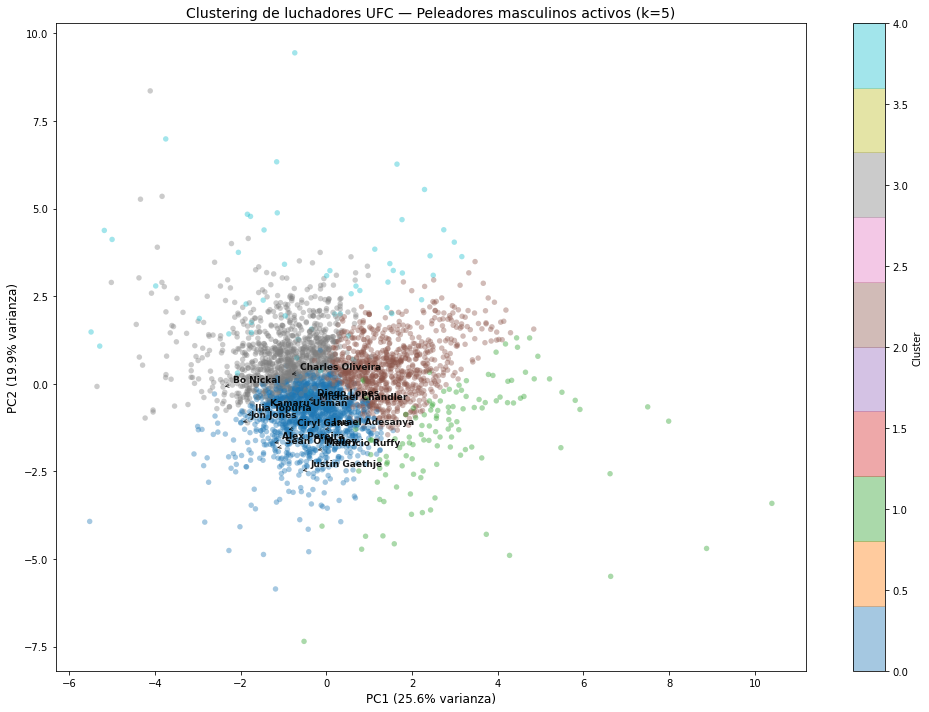

In [14]:
# Scatter PCA 2D con luchadores conocidos etiquetados
fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df_clean['cluster'].values, cmap='tab10',
                     alpha=0.4, s=30, edgecolors='none')
plt.colorbar(scatter, label='Cluster', ax=ax)

# Etiquetar luchadores conocidos
for _, row in df_known.iterrows():
    idx = df_clean[df_clean['NAME'] == row['NAME']].index[0]
    pos = df_clean.index.get_loc(idx)
    ax.annotate(row['NAME'], (X_pca[pos, 0], X_pca[pos, 1]),
                fontsize=9, fontweight='bold', alpha=0.9,
                arrowprops=dict(arrowstyle='->', color='black', lw=0.5),
                textcoords="offset points", xytext=(10, 5))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=12)
ax.set_title(f'Clustering de luchadores UFC — Peleadores masculinos activos (k={k_optimal})', fontsize=14)
plt.tight_layout()
plt.show()

---

## Ejercicio 2: Matchmaker para UFC Freedom 250 (Casa Blanca)

El **14 de junio de 2026**, la UFC celebrará el evento **UFC Freedom 250** en el Jardín Sur de la Casa Blanca, con motivo del 250 aniversario de la independencia de EE.UU. La cartelera oficial tiene **solo 6 peleas**:

| Pelea | Categoría | Contexto |
|-------|-----------|----------|
| **Ilia Topuria** vs. **Justin Gaethje** | Peso Ligero (155 lbs) | Unificación del título |
| **Alex Pereira** vs. **Ciryl Gane** | Peso Pesado (título interino) | Pereira busca título en 3ª categoría |
| **Mauricio Ruffy** vs. **Michael Chandler** | Peso Ligero | |
| **Sean O'Malley** vs. **Aiemann Zahabi** | Peso Gallo (135 lbs) | |
| **Bo Nickal** vs. **Kyle Daukaus** | Peso Mediano (185 lbs) | |
| **Diego Lopes** vs. **Steve García** | Peso Pluma (145 lbs) | |

### El problema

Imagina que eres el **matchmaker** de la UFC y uno (o varios) de los luchadores se lesiona antes del evento. Tu trabajo consiste en diseñar un **sistema de sustitución basado en los clusters** que has descubierto en el Ejercicio 1.

**Restricciones del sustituto:**
1. Debe competir en la misma categoría de peso (o cercana).
2. No puede ser ninguno de los otros 11 luchadores ya en la cartelera.
3. Debe ser un peleador masculino activo (ya filtrado en `df_clean`).
4. La lógica de búsqueda debe apoyarse **fundamentalmente en el clustering**, no en distancias punto a punto.


### Identificar los luchadores de la cartelera

In [15]:
# Cartelera UFC Freedom 250
cartelera = {
    'Ilia Topuria':     {'opponent': 'Justin Gaethje',  'weight_class': 155},
    'Justin Gaethje':   {'opponent': 'Ilia Topuria',    'weight_class': 155},
    'Alex Pereira':     {'opponent': 'Ciryl Gane',      'weight_class': 205},
    'Ciryl Gane':       {'opponent': 'Alex Pereira',    'weight_class': 245},
    "Sean O'Malley":    {'opponent': 'Aiemann Zahabi',  'weight_class': 135},
    'Aiemann Zahabi':   {'opponent': "Sean O'Malley",   'weight_class': 135},
    'Mauricio Ruffy':   {'opponent': 'Michael Chandler','weight_class': 155},
    'Michael Chandler': {'opponent': 'Mauricio Ruffy',  'weight_class': 155},
    'Bo Nickal':        {'opponent': 'Kyle Daukaus',    'weight_class': 185},
    'Kyle Daukaus':     {'opponent': 'Bo Nickal',       'weight_class': 185},
    'Diego Lopes':      {'opponent': 'Steve Garcia',   'weight_class': 145},
    'Steve Garcia':     {'opponent': 'Diego Lopes',    'weight_class': 145},
}

cartelera_names = list(cartelera.keys())
df_cartelera = df_clean[df_clean['NAME'].isin(cartelera_names)]

print(f"Luchadores de la cartelera encontrados: {len(df_cartelera)}/{len(cartelera_names)}")
if len(df_cartelera) < len(cartelera_names):
    missing = set(cartelera_names) - set(df_cartelera['NAME'].values)
    print(f"⚠️  No encontrados en dataset activo: {missing}")
print()
print(df_cartelera[['NAME', 'WEIGHT', 'cluster'] + feature_columns].to_string(index=False))

Luchadores de la cartelera encontrados: 11/12
⚠️  No encontrados en dataset activo: {'Kyle Daukaus'}

            NAME  WEIGHT  cluster  SLpM  Str. Acc.  SApM  Str. Def.  TD Avg.  TD Acc.  TD Def.  Sub. Avg.
Michael Chandler   155.0        0  4.04         49  4.52         43     1.96       41       61        0.6
  Justin Gaethje   155.0        0  6.48         58  7.05         51     0.33       40       74        0.0
      Ciryl Gane   247.0        0  5.29         61  2.33         60     0.68       25       47        0.6
    Steve Garcia   145.0        0  5.39         49  2.12         59     0.86       40       88        0.4
     Diego Lopes   145.0        0  3.83         47  4.56         45     0.88       50       68        1.4
       Bo Nickal   185.0        3  3.35         61  2.07         59     3.10       55      100        2.5
   Sean O'Malley   135.0        0  6.05         60  3.40         60     0.24       42       60        0.2
    Alex Pereira   205.0        0  5.16         62

### Ejercicio 2.1: Diseña tu estrategia de matchmaking (1 punto)

Antes de escribir código, reflexiona y **explica con tus propias palabras** qué estrategia vas a seguir para detectar sustitutos.

Para mantener el espectáculo, busccaremos un peleador similar aplicando los siguientes filtros:
-El peleador sustituto no puede estar en la cartelera (elimino a los 11)
-El peleador tiene que estar activo (aplico el filtro del 1.1, el de LAST_FIGHT_DATE>= 01/01/2023)
-Tiene que tener un peso similar (me quedo exclusivamente con los boxeadores de la misma categoría de peso)
-Tiene que tener el mismo estilo que el sustituido (saco el cluster del lesionado y filtro a que queden sólo boxeadores del mismo estilo)
-Intento que sea lo más parecido al sustituido calculando la distancia euclidea al centroide del cluster y ordenando de menor a mayor

### Ejercicio 2.2: Implementa tu sistema de búsqueda de sustitutos (3 puntos)

Escribe una función `buscar_sustituto` que, dado el nombre de un luchador lesionado, devuelva una lista de candidatos a sustituirlo. La función debe:

- Recibir como parámetros al menos: el nombre del luchador lesionado, el DataFrame con los datos, y el diccionario de la cartelera.
- Aplicar la estrategia y los filtros que hayas decidido en el paso anterior.
- Devolver un DataFrame con los candidatos ordenados según tu criterio de selección.

In [33]:
# Solución
def buscar_sustituto(fighter_name, df_data, cartelera_dict, kmeans_model, scaler_model, feature_cols, n_candidates=5):

    # Localizar al luchador lesionado (si no se encuentra, retornar None)
    fighter_row = df_data[df_data['NAME'] == fighter_name]
    if fighter_row.empty:
        print(f"⚠️ {fighter_name} no encontrado en el dataset.")
        return None
        
    # Sacamos el valor del cluster y el peso de la pelea original
    fighter_cluster = fighter_row['cluster'].values[0]
    fighter_weight = cartelera_dict[fighter_name]['weight_class']
       
    
    # Centroide del cluster del lesionado (en espacio escalado)
    centroid = kmeans_model.cluster_centers_[fighter_cluster]
    
    # 1. Filtro: Peleadores excluidos (los que ya están en la cartelera)
    excluded = list(cartelera_dict.keys())
    
    # Aplicamos todos los filtros de tu estrategia
    mask = (
        (~df_data['NAME'].isin(excluded)) &             # No puede estar en la cartelera
        (df_data['WEIGHT'] == fighter_weight) &         # Mismo peso estricto
        (df_data['cluster'] == fighter_cluster)         # Mismo estilo (cluster)
        # Nota: El filtro de actividad (>= 2023) ya está implícito porque usamos df_data que viene de df_clean
    )
    
    candidates = df_data[mask].copy()
    
    if candidates.empty:
        print(f"   Sin candidatos disponibles en el cluster {fighter_cluster} para {fighter_weight} lbs.")
        return None
    
    # Calcular distancia al centroide para cada candidato (tu último punto de la estrategia)
    candidate_features = scaler_model.transform(candidates[feature_cols].values)
    candidates['dist_centroide'] = [
        np.linalg.norm(row - centroid) for row in candidate_features
    ]
    
    # Ordenar: menor distancia al centroide = estilo más parecido al sustituido
    candidates = candidates.sort_values('dist_centroide')
    
    cols_out = ['NAME', 'WEIGHT', 'cluster', 'dist_centroide'] + feature_cols
    return candidates[cols_out].head(n_candidates)

print("Función buscar_sustituto definida con la estrategia exacta.")
print("Criterio: mismo cluster → filtro de peso → orden por cercanía al centroide.")

Función buscar_sustituto definida con la estrategia exacta.
Criterio: mismo cluster → filtro de peso → orden por cercanía al centroide.


### Prueba tu sistema con lesiones simuladas

Simula la lesión de **al menos 3 luchadores** de peleas distintas y muestra los sustitutos propuestos por tu función. Para cada caso:

1. Indica qué luchador se lesiona, su pelea original y su cluster.
2. Muestra la tabla de candidatos devuelta por tu función.
3. **Explica brevemente** por qué el sustituto nº 1 es una buena elección (o por qué no lo es).

In [ ]:
# Simulamos la lesión de 3 luchadores de peleas distintas
injured_fighters = ['Ilia Topuria', 'Bo Nickal', 'Diego Lopes']

resultados_lesiones = {}  # guardar para visualización posterior

for fighter in injured_fighters:
    opponent = cartelera[fighter]['opponent']
    weight = cartelera[fighter]['weight_class']
    fighter_cl = df_clean[df_clean['NAME'] == fighter]['cluster']
    cl_val = fighter_cl.values[0] if len(fighter_cl) > 0 else '?'
    
    print('=' * 75)
    print(f"> LESIÓN: {fighter} ({weight} lbs) — Cluster {cl_val}")
    print(f"   Pelea original: {fighter} vs. {opponent}")
    print('-' * 75)
    
    subs = buscar_sustituto(...)
    
    if subs is not None:
        print(subs.to_string(index=False))
        resultados_lesiones[fighter] = subs
    print()

### Visualiza y justifica tu propuesta

Crea **al menos una visualización** que muestre de forma clara cómo se relacionan el luchador lesionado, su sustituto propuesto y el resto de luchadores del cluster. Puedes usar:

- El espacio PCA 2D (ya calculado en `X_pca`), destacando al lesionado, al sustituto y a los compañeros de cluster.
- Un gráfico radar comparando los perfiles del lesionado y del sustituto.
- Cualquier otra visualización que consideres adecuada.

Explica qué se observa en la visualización y si refuerza o contradice la elección del sustituto.

In [ ]:
injured = 'Ilia Topuria'
# Radar comparativo ---
if subs is not None:
    best_sub_name = subs.iloc[0]['NAME']
    
    row1 = df_clean[df_clean['NAME'] == injured][feature_columns].values[0]
    row2 = df_clean[df_clean['NAME'] == best_sub_name][feature_columns].values[0]
    
    mins = df_clean[feature_columns].min().values
    maxs = df_clean[feature_columns].max().values
    row1_norm = (row1 - mins) / (maxs - mins)
    row2_norm = (row2 - mins) / (maxs - mins)
    
    N = len(feature_columns)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    row1_norm = np.append(row1_norm, row1_norm[0])
    row2_norm = np.append(row2_norm, row2_norm[0])
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.plot(angles, row1_norm, 'o-', linewidth=2, label=injured, color='red')
    ax.fill(angles, row1_norm, alpha=0.15, color='red')
    ax.plot(angles, row2_norm, 's-', linewidth=2, label=best_sub_name, color='green')
    ax.fill(angles, row2_norm, alpha=0.15, color='green')
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_columns, fontsize=10)
    ax.set_title(f'{injured} vs {best_sub_name}\nComparación de perfil de combate',
                 fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    plt.tight_layout()
    plt.show()

*✍️ ¿Qué se observa? ¿Refuerza la elección del sustituto?*
